In [ ]:
# ============================================================
# Credit Card Fraud Detection (Realistic & Advanced Version)
# ============================================================
# Models: Random Forest, XGBoost, LightGBM, SVM, Isolation Forest
# Features: Controlled SMOTE, Feature Engineering
# Metrics: Precision, Recall, F1, ROC-AUC, PR-AUC
# Visuals: ROC, PR Curve, Confusion Matrix, Comparison Graphs
# ============================================================

In [ ]:
# ---------------------- Imports ----------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, roc_auc_score,
                             precision_score, recall_score, f1_score,
                             average_precision_score,
                             precision_recall_curve, roc_curve)

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from imblearn.over_sampling import SMOTE

In [ ]:
# ---------------------- Load Dataset ----------------------
print("Loading dataset...")

data = pd.read_csv("creditcard.csv", on_bad_lines='skip')

# Convert to numeric (fix errors)
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')

data.dropna(inplace=True)

# Smaller sample for realism
data = data.sample(n=20000, random_state=42)

print("Dataset shape:", data.shape)
print("\nClass distribution:\n", data['Class'].value_counts())

Loading dataset...
Dataset shape: (20000, 31)

Class distribution:
 Class
0.0    19967
1.0       33
Name: count, dtype: int64


In [ ]:
# ---------------------- Feature Engineering ----------------------
print("\nFeature engineering...")

data['Hour'] = (data['Time'] // 3600) % 24
data['Is_Night'] = ((data['Hour'] >= 22) | (data['Hour'] <= 6)).astype(int)

data['Log_Amount'] = np.log1p(data['Amount'])
data['V1_V2_ratio'] = data['V1'] / (data['V2'] + 1e-5)

print("Done.")


Feature engineering...
Done.


In [ ]:
# ---------------------- Prepare Data ----------------------
X = data.drop(['Class', 'Time'], axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# ---------------------- SMOTE ----------------------
print("\nApplying controlled SMOTE...")

sm = SMOTE(random_state=42, sampling_strategy=0.2)
X_train, y_train = sm.fit_resample(X_train, y_train)

print("After SMOTE:\n", pd.Series(y_train).value_counts())


Applying controlled SMOTE...
After SMOTE:
 Class
0.0    15974
1.0     3194
Name: count, dtype: int64


In [ ]:
# ---------------------- Models ----------------------
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    eval_metric='logloss',
    use_label_encoder=False
)

lgbm = LGBMClassifier(n_estimators=100, max_depth=6)

svm = SVC(probability=True)

iso = IsolationForest(contamination=0.02, random_state=42)

models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
    "SVM": svm,
    "Isolation Forest": iso
}

In [ ]:
# ---------------------- Training & Evaluation ----------------------
results = []
probabilities = {}
predictions = {}

print("\nTraining models...\n")

for name, model in models.items():

    print(f"===== {name} =====")

    # -------- Isolation Forest (unsupervised) --------
    if name == "Isolation Forest":
        model.fit(X_train)

        y_pred = model.predict(X_test)
        y_pred = np.where(y_pred == -1, 1, 0)

        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        roc = np.nan
        pr = np.nan

    # -------- Supervised Models --------
    else:
        model.fit(X_train, y_train)

        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)   # realistic threshold

        probabilities[name] = y_prob

        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)

        roc = roc_auc_score(y_test, y_prob)
        pr = average_precision_score(y_test, y_prob)

    predictions[name] = y_pred

    # -------- Confusion Matrix + Cost --------
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    cost = (fn * 500) + (fp * 10)

    # -------- Print Output --------
    print(f"Precision: {precision:.3f}")
    print(f"Recall:    {recall:.3f}")
    print(f"F1 Score:  {f1:.3f}")
    print(f"ROC-AUC:   {roc:.3f}")
    print(f"Cost:      {cost}")
    print("-" * 40)

    # -------- Store Results --------
    results.append([name, precision, recall, f1, roc, pr, cost])


# ---------------------- Create Comparison Table ----------------------
results_df = pd.DataFrame(
    results,
    columns=["Model", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC", "Cost"]
)

print("\nFinal Model Comparison:\n")
print(results_df)


Training models...

===== Random Forest =====
Precision: 1.000
Recall:    0.714
F1 Score:  0.833
ROC-AUC:   0.999
Cost:      1000
----------------------------------------
===== XGBoost =====
Precision: 0.857
Recall:    0.857
F1 Score:  0.857
ROC-AUC:   1.000
Cost:      510
----------------------------------------
===== LightGBM =====
[LightGBM] [Info] Number of positive: 3194, number of negative: 15974
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013928 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8415
[LightGBM] [Info] Number of data points in the train set: 19168, number of used features: 33
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166632 -> initscore=-1.609688
[LightGBM] [Info] Start training from score -1.609688
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning]

In [ ]:
# ---------------------- Save Results ----------------------
results_df.to_csv("model_results.csv", index=False)

print("\nSaved results to model_results.csv")


Saved results to model_results.csv


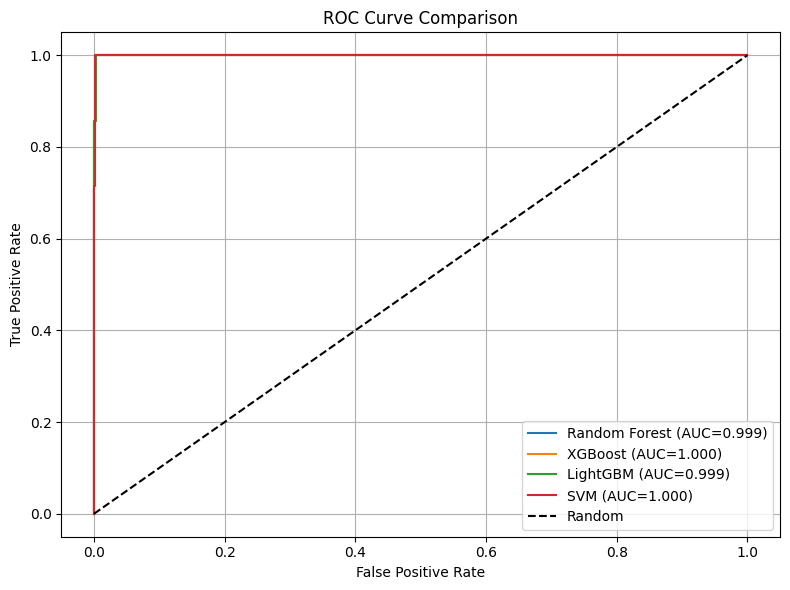

In [ ]:
# ---------------------- ROC Curve ----------------------
plt.figure(figsize=(8,6))

for name, prob in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

# Random baseline
plt.plot([0,1], [0,1], 'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("roc_curve.png")
plt.show()

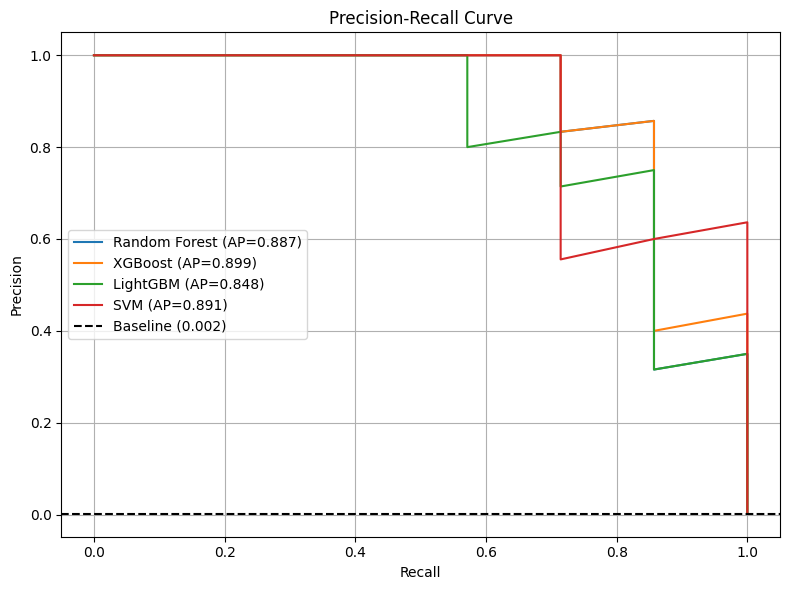

In [ ]:
# ---------------------- PR Curve ----------------------
plt.figure(figsize=(8,6))

for name, prob in probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

# Baseline
baseline = y_test.mean()
plt.axhline(y=baseline, linestyle='--', color='black',
            label=f"Baseline ({baseline:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("pr_curve.png")
plt.show()

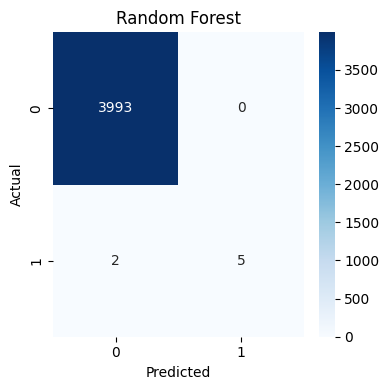

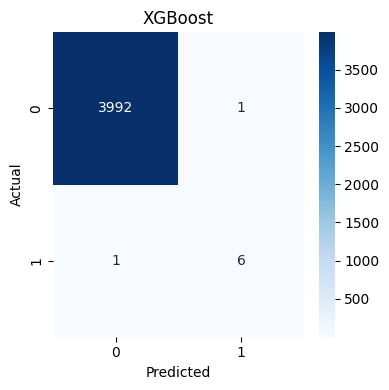

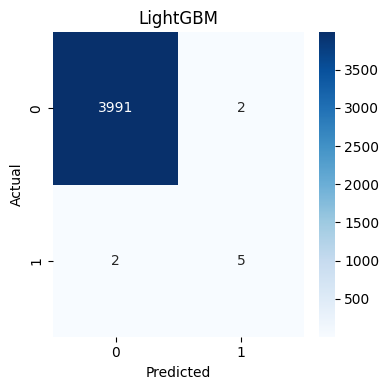

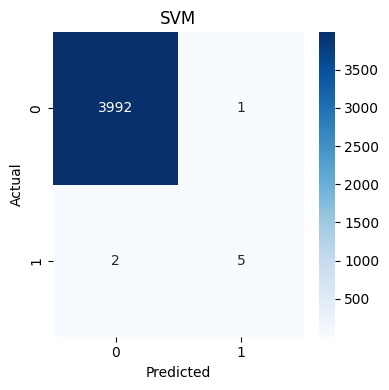

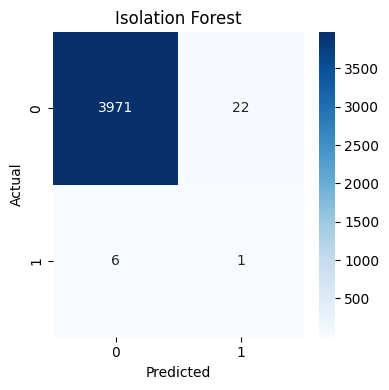

In [ ]:
# ---------------------- Confusion Matrices ----------------------
import seaborn as sns

for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.savefig(f"cm_{name}.png")
    plt.show()

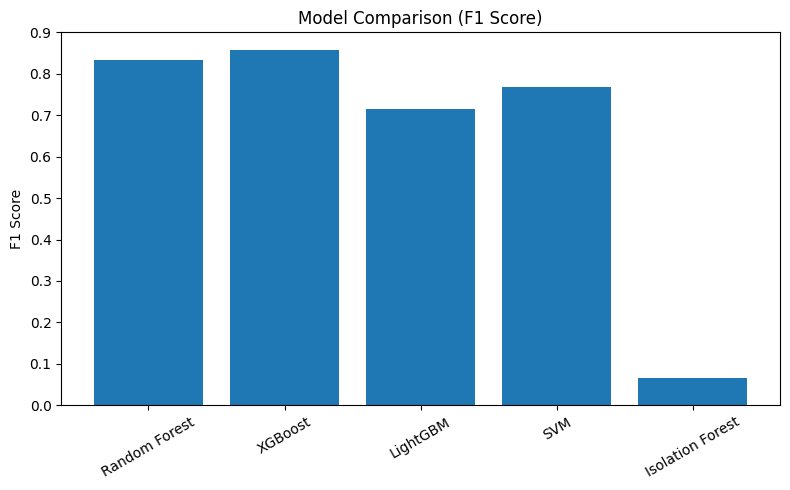

In [ ]:
# ---------------------- F1 Comparison ----------------------
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["F1"])
plt.xticks(rotation=30)
plt.ylabel("F1 Score")
plt.title("Model Comparison (F1 Score)")

plt.tight_layout()
plt.savefig("f1_comparison.png")
plt.show()

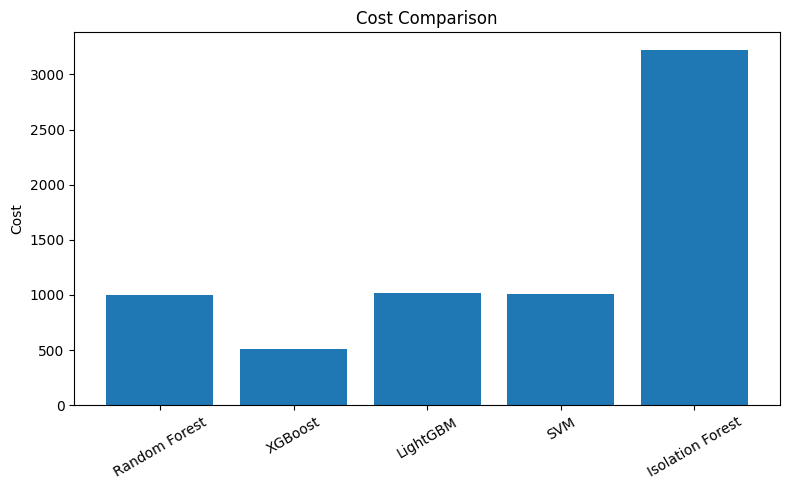

In [ ]:
# ---------------------- Cost Analysis ----------------------
plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Cost"])
plt.xticks(rotation=30)
plt.ylabel("Cost")
plt.title("Cost Comparison")

plt.tight_layout()
plt.savefig("cost_analysis.png")
plt.show()

In [ ]:
# ---------------------- Best Model ----------------------
best_model = results_df.loc[results_df["F1"].idxmax()]

print("\nBest Model based on F1 Score:\n")
print(best_model)


Best Model based on F1 Score:

Model         XGBoost
Precision    0.857143
Recall       0.857143
F1           0.857143
ROC-AUC      0.999642
PR-AUC       0.899235
Cost              510
Name: 1, dtype: object
